In [1]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
from vae_model import VAE, vae_loss
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 100
patience = 10  
best_loss = float('inf')
patience_counter = 0

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - 1e-4:  
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement, patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


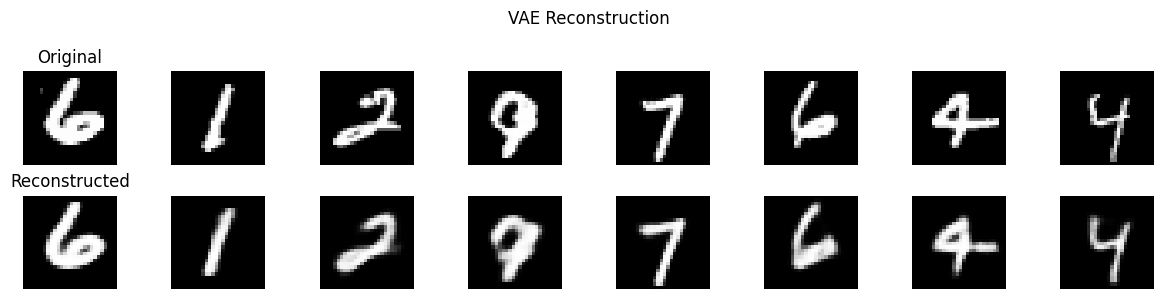

In [4]:
model.eval() 
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    x_recon, _, _ = model(x)

x = x.cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()


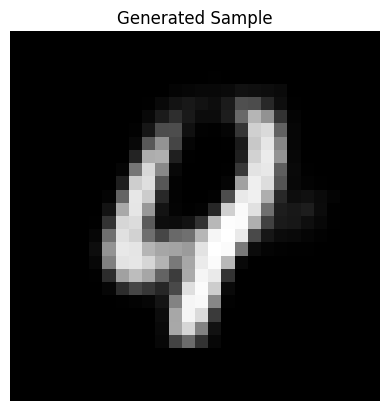

In [14]:
model.eval()
latent_dim = model.latent_dim  

z = torch.randn(1, latent_dim).to(device)

with torch.no_grad():
    x_gen = model.decoder(z).view(1, 1, 28, 28).cpu()

plt.imshow(x_gen[0, 0], cmap='gray')
plt.title("Generated Sample")
plt.axis("off")
plt.show()

In [26]:
from torch.utils.data import Subset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
epochs = 100
patience = 10  
best_loss = float('inf')
patience_counter = 0

transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)

# Use only the first 10,000 samples
train_dataset = Subset(full_dataset, range(10000))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

latent_dim = 20
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(device)
        optimizer.zero_grad()
        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")

    # Early stopping check
    if avg_loss < best_loss - 1e-4:  
        best_loss = avg_loss
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement, patience {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1, Loss: 245.8726
Epoch 2, Loss: 176.7053
Epoch 3, Loss: 153.5832
Epoch 4, Loss: 142.5994
Epoch 5, Loss: 134.7361
Epoch 6, Loss: 129.4968
Epoch 7, Loss: 125.7435
Epoch 8, Loss: 122.8110
Epoch 9, Loss: 120.3738
Epoch 10, Loss: 118.5715
Epoch 11, Loss: 117.0311
Epoch 12, Loss: 115.8844
Epoch 13, Loss: 114.8752
Epoch 14, Loss: 113.9137
Epoch 15, Loss: 113.2333
Epoch 16, Loss: 112.7171
Epoch 17, Loss: 111.9027
Epoch 18, Loss: 111.2794
Epoch 19, Loss: 110.8216
Epoch 20, Loss: 110.3332
Epoch 21, Loss: 110.0510
Epoch 22, Loss: 109.6454
Epoch 23, Loss: 109.2273
Epoch 24, Loss: 108.9479
Epoch 25, Loss: 108.5810
Epoch 26, Loss: 108.2380
Epoch 27, Loss: 107.9956
Epoch 28, Loss: 107.8333
Epoch 29, Loss: 107.6665
Epoch 30, Loss: 107.3862
Epoch 31, Loss: 107.0684
Epoch 32, Loss: 106.8885
Epoch 33, Loss: 106.8293
Epoch 34, Loss: 106.5570
Epoch 35, Loss: 106.4162
Epoch 36, Loss: 106.2893
Epoch 37, Loss: 106.1232
Epoch 38, Loss: 105.8920
Epoch 39, Loss: 105.7018
Epoch 40, Loss: 105.6831
Epoch 41,

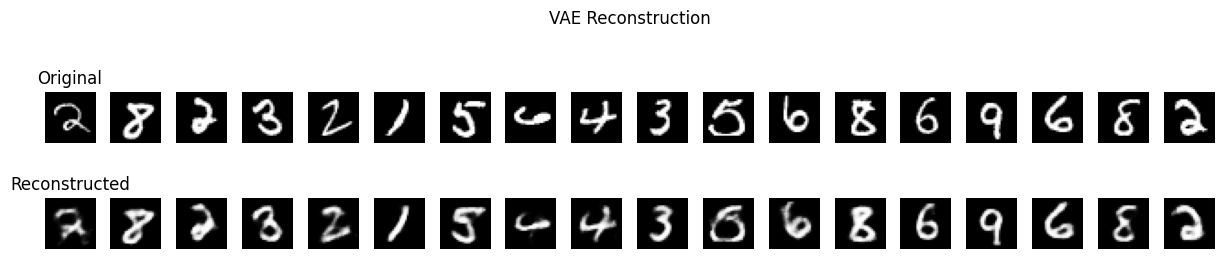

In [21]:
model.eval() 
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=18, shuffle=True)

x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    x_recon, _, _ = model(x)

x = x.cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 18, figsize=(12, 3))
for i in range(18):
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()


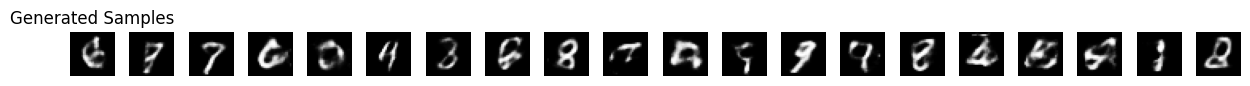

In [27]:
model.eval()
latent_dim = model.latent_dim  
# generate latent vector k latent vector z
k = 20  # Number of latent vectors to generate 
z = torch.randn(k, latent_dim).to(device)
with torch.no_grad():
    x_gen = model.decoder(z).view(k, 1, 28, 28).cpu()   
plt.figure(figsize=(12, 3))
for i in range(k):
    plt.subplot(2, k, i + 1)
    plt.imshow(x_gen[i, 0], cmap='gray')
    plt.axis('off')
    if i == 0:
        plt.title("Generated Samples")
plt.tight_layout()
plt.show()

# CVAE

In [1]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
from torch.utils.data import Subset
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 100
lr = 1e-3

# Load MNIST
transform = transforms.ToTensor()
full_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_dataset = Subset(full_dataset, range(40000))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# One-hot encoding helper
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes).float()

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x = x.view(-1, 784).to(device)
        y = one_hot(y).to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")


Epoch 1, Loss: 178.9234
Epoch 2, Loss: 127.1244
Epoch 3, Loss: 117.1875
Epoch 4, Loss: 112.7043
Epoch 5, Loss: 110.0952
Epoch 6, Loss: 108.3007
Epoch 7, Loss: 106.9782
Epoch 8, Loss: 105.9515
Epoch 9, Loss: 105.1061
Epoch 10, Loss: 104.4049
Epoch 11, Loss: 103.8071
Epoch 12, Loss: 103.2929
Epoch 13, Loss: 102.9100
Epoch 14, Loss: 102.4893
Epoch 15, Loss: 102.1829
Epoch 16, Loss: 101.8658
Epoch 17, Loss: 101.5484
Epoch 18, Loss: 101.3501
Epoch 19, Loss: 101.0183
Epoch 20, Loss: 100.8789
Epoch 21, Loss: 100.6473
Epoch 22, Loss: 100.4900
Epoch 23, Loss: 100.3037
Epoch 24, Loss: 100.1047
Epoch 25, Loss: 100.0430
Epoch 26, Loss: 99.8399
Epoch 27, Loss: 99.7374
Epoch 28, Loss: 99.5521
Epoch 29, Loss: 99.4368
Epoch 30, Loss: 99.3357
Epoch 31, Loss: 99.2404
Epoch 32, Loss: 99.1232
Epoch 33, Loss: 98.9908
Epoch 34, Loss: 98.9334
Epoch 35, Loss: 98.8582
Epoch 36, Loss: 98.8234
Epoch 37, Loss: 98.6955
Epoch 38, Loss: 98.5716
Epoch 39, Loss: 98.5259
Epoch 40, Loss: 98.4283
Epoch 41, Loss: 98.3791


In [2]:
# save the model to model_saved folder
sample_size = 40000
import os
if not os.path.exists("model_saved"):
    os.makedirs("model_saved")
torch.save(model.state_dict(), f"model_saved/cvae_mnist_{sample_size}.pth")
print(f"Model saved to model_saved/cvae_mnist_{sample_size}.pth")

Model saved to model_saved/cvae_mnist_40000.pth


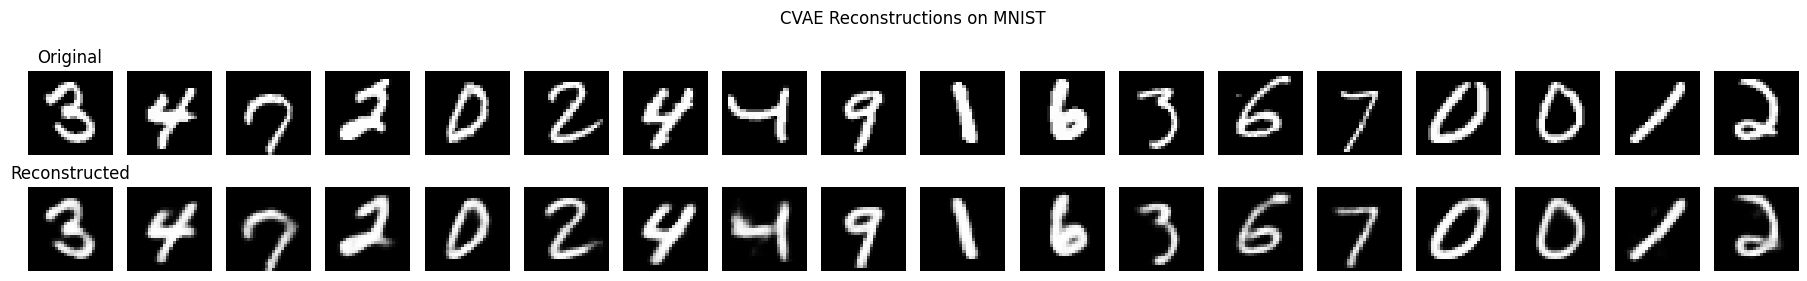

In [3]:
# Set model to evaluation mode
model.eval()

# Prepare test data
transform = transforms.ToTensor()
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=18, shuffle=True)

# Get a batch
x, y = next(iter(test_loader))
x = x.view(-1, 784).to(device)
y = F.one_hot(y, num_classes=10).float().to(device)

# Reconstruct images
with torch.no_grad():
    x_recon, _, _ = model(x, y)

# Move data to CPU for visualization
x = x.view(-1, 1, 28, 28).cpu()
x_recon = x_recon.view(-1, 1, 28, 28).cpu()

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 18, figsize=(18, 3))
for i in range(18): 
    axes[0, i].imshow(x[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstructed")
plt.suptitle("CVAE Reconstructions on MNIST")
plt.tight_layout()
plt.show()


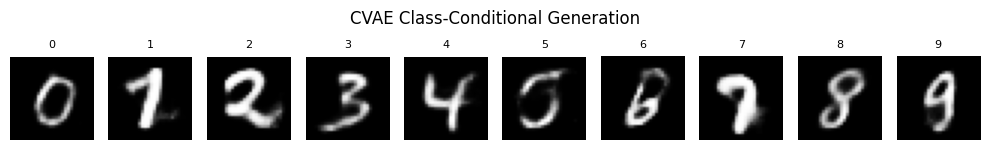

In [5]:
model.eval()

# Generate digits for labels 0 through 9
num_classes = 10
latent_dim = model.latent_dim
device = next(model.parameters()).device  # get model device

with torch.no_grad():
    # Sample one latent vector per class
    z = torch.randn(num_classes, latent_dim).to(device)

    # One-hot encode class labels 0-9
    y = torch.eye(num_classes).to(device)

    # Decode
    generated = model.decode(z, y).view(-1, 1, 28, 28).cpu()

# Plot
fig, axes = plt.subplots(1, num_classes, figsize=(num_classes, 1.5))
for i in range(num_classes):
    axes[i].imshow(generated[i].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(i), fontsize=8)
plt.suptitle("CVAE Class-Conditional Generation", fontsize=12)
plt.tight_layout()
plt.show()


## generate synthetic data

In [2]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from cvae_model import CVAE 
import os

latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
#os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
os.chdir("/home/qiyuanliu/")  
model.load_state_dict(torch.load("model_saved/cvae_mnist_40000.pth"))
model.eval()

/tmp/ipykernel_4165116/2082692406.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_saved/cvae_mnist_40000.pth"))


CVAE(
  (fc1): Linear(in_features=794, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=30, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

In [ ]:
import torch
import torch.nn.functional as F

model.eval()

n_per_class = 600000
num_classes = 10
total_samples = n_per_class * num_classes
latent_dim = model.latent_dim
device = next(model.parameters()).device

z = torch.randn(total_samples, latent_dim).to(device)
y = torch.arange(num_classes).repeat_interleave(n_per_class)
y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

with torch.no_grad():
    gen_imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()  # shape: [60000, 1, 28, 28]


In [3]:
import torch
import torch.nn.functional as F

def generate_images_in_batches(model, total_samples, latent_dim, num_classes, batch_size=10000, device='cuda'):
    model.eval()
    generated_images = []
    all_labels = []

    for start in range(0, total_samples, batch_size):
        end = min(start + batch_size, total_samples)
        batch_size_actual = end - start

        # Generate z and y
        z = torch.randn(batch_size_actual, latent_dim).to(device)
        y = torch.arange(num_classes).repeat_interleave(total_samples // num_classes)[start:end]
        y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

        with torch.no_grad():
            imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()
            generated_images.append(imgs)
            all_labels.append(y)

    images = torch.cat(generated_images, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return images, labels



In [4]:
latent_dim = model.latent_dim
device = next(model.parameters()).device
gen_imgs,y = generate_images_in_batches(
    model=model,
    total_samples=6000000,
    latent_dim=latent_dim,
    num_classes=10,
    batch_size=10000,
    device=device
)
print("Generated shape:", gen_imgs.shape)  # Should be [6000000, 1, 28, 28]


Generated shape: torch.Size([6000000, 1, 28, 28])


In [5]:
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
save_path = "data_saved/synthetic_mnist_cvae_6000000.pt"
torch.save({
    'images': gen_imgs,    # Tensor [6000000, 1, 28, 28]
    'labels': y            # Tensor [6000000]
}, save_path)

print(f"Saved to {save_path}")


Saved to data_saved/synthetic_mnist_cvae_6000000.pt


/tmp/ipykernel_2677112/1602137459.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")


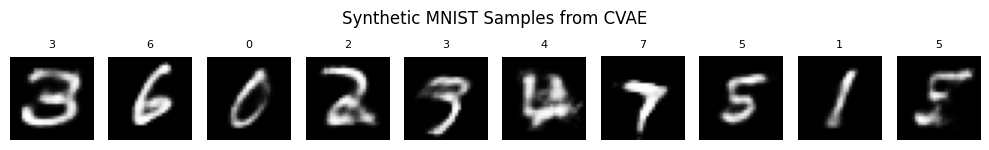

In [13]:
import matplotlib.pyplot as plt
data = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")
images = data['images']   # [60000, 1, 28, 28]
labels = data['labels']   # [60000]

num_samples = 10
indices = torch.randperm(len(images))[:num_samples]

fig, axes = plt.subplots(1, num_samples, figsize=(num_samples, 1.5))
for i, idx in enumerate(indices):
    axes[i].imshow(images[idx].squeeze(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(str(labels[idx].item()), fontsize=8)
plt.suptitle("Synthetic MNIST Samples from CVAE", fontsize=12)
plt.tight_layout()
plt.show()

## Train the Discriminator

In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset

# real MNIST (60,000）
transform = transforms.ToTensor()
mnist = datasets.MNIST('./data', train=True, download=True, transform=transform)
real_imgs = torch.stack([mnist[i][0] for i in range(60000)])  # shape: [60000, 1, 28, 28]
real_labels = torch.ones(60000, 1)  # label = 1

# synthetic data（60,000）
data = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")
fake_imgs = data['images'][:60000]  # shape: [60000, 1, 28, 28]
fake_labels = torch.zeros(60000, 1)  # label = 0

X_all = torch.cat([real_imgs, fake_imgs], dim=0)
y_all = torch.cat([real_labels, fake_labels], dim=0)

perm = torch.randperm(len(X_all))
X_all = X_all[perm]
y_all = y_all[perm]

from torch.utils.data import TensorDataset
disc_dataset = TensorDataset(X_all, y_all)
disc_loader = DataLoader(disc_dataset, batch_size=128, shuffle=True)


/tmp/ipykernel_2677112/2256974355.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")


In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from discriminator import Discriminator
from torch import nn
D = Discriminator().to(device)
optimizer = torch.optim.Adam(D.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

for epoch in range(10):

    D.train()
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in disc_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        preds = D(x_batch)
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = (preds > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

    acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {acc*100:.2f}%")


Epoch 1, Loss: 84.5858, Accuracy: 96.27%
Epoch 2, Loss: 28.8508, Accuracy: 98.92%
Epoch 3, Loss: 21.7952, Accuracy: 99.19%
Epoch 4, Loss: 16.7605, Accuracy: 99.39%
Epoch 5, Loss: 17.8801, Accuracy: 99.34%
Epoch 6, Loss: 14.2571, Accuracy: 99.47%
Epoch 7, Loss: 12.9986, Accuracy: 99.51%
Epoch 8, Loss: 10.6763, Accuracy: 99.60%
Epoch 9, Loss: 8.8672, Accuracy: 99.67%
Epoch 10, Loss: 9.2866, Accuracy: 99.62%


In [16]:
save_path = "model_saved/discriminator_mnist_cvae_2.pth"
torch.save(D.state_dict(), save_path)

## Filter

In [6]:
import torch
from torch.utils.data import DataLoader
from discriminator import Discriminator
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
D = Discriminator().to(device)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
D.eval()

data = torch.load("data_saved/synthetic_mnist_cvae_6000000.pt")
synthetic_images = data['images']  # [60000, 1, 28, 28]

synthetic_loader = DataLoader(synthetic_images, batch_size=512)

all_probs = []

with torch.no_grad():
    for batch in synthetic_loader:
        batch = batch.to(device)
        probs = D(batch)  # [batch_size, 1], already sigmoid activated
        all_probs.append(probs.cpu())

all_probs = torch.cat(all_probs, dim=0)

print(f"Got probabilities for {all_probs.shape[0]} synthetic samples.")


/tmp/ipykernel_4165116/2618065355.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  D.load_state_dict(torch.load("model_saved/discriminator_mnist_cvae_2.pth"))
/tmp/ipyker

Got probabilities for 6000000 synthetic samples.


In [8]:
print(data['images'].shape)
print(data['labels'].shape)

torch.Size([6000000, 1, 28, 28])
torch.Size([6000000])


In [ ]:
# Flatten probs to shape [N]
probs = all_probs.squeeze(1)

# Load images and labels
images = data['images']      # [N, 1, 28, 28]
labels = data['labels']      # [N]

# Create mask for p > 0.5
mask = probs > 0.5

# Apply mask
filtered_images = images[mask]
filtered_labels = labels[mask]

print(f"Selected {filtered_images.shape[0]} samples with p > 0.5")

# Save to file
torch.save({
    'images': filtered_images,
    'labels': filtered_labels
}, "data_saved/synthetic_mnist_filtered_pgt05.pt")

print("Saved to: data_saved/synthetic_mnist_filtered_pgt05.pt")


Selected 75242 samples with p > 0.5
Saved to: data_saved/synthetic_mnist_filtered_pgt05.pt


In [11]:
filtered_labels.shape

torch.Size([75242])

In [7]:
torch.save(all_probs, "data_saved/synthetic_mnist_cvae_probs_larger.pt")
print("✅ Probabilities saved.")

✅ Probabilities saved.


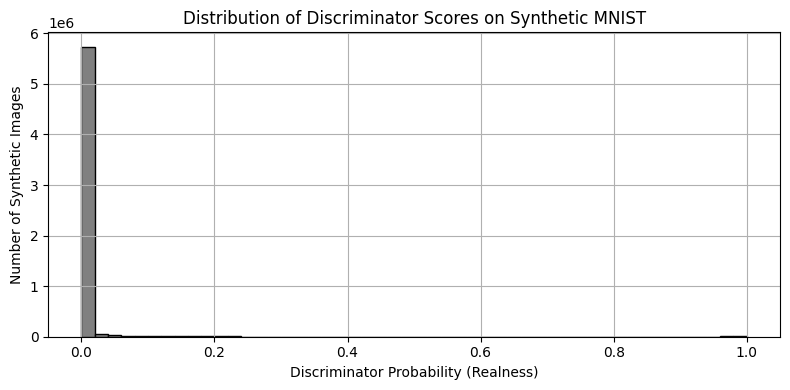

In [9]:
import torch
import matplotlib.pyplot as plt
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
#probs = torch.load("data_saved/synthetic_mnist_cvae_probs_2.pt")  # shape: [60000, 1]
probs = all_probs#probs.squeeze().numpy()  # shape: [60000]
probs = probs.squeeze().numpy()  # shape: [60000]
plt.figure(figsize=(8, 4))
plt.hist(probs, bins=50, color='gray', edgecolor='black')
plt.xlabel("Discriminator Probability (Realness)")
plt.ylabel("Number of Synthetic Images")
plt.title("Distribution of Discriminator Scores on Synthetic MNIST")
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
all_probs.max()

tensor(1.0000)

In [12]:
# how many synthetic images have a probability greater than 0.5?
a=0.5
print(f"Number of synthetic images with probability > 0.5: {all_probs[all_probs > a].numel()} out of {all_probs.numel()} total samples.")
print(f"Percentage: {100 * all_probs[all_probs > a].numel() / all_probs.numel():.2f}%")

Number of synthetic images with probability > 0.5: 75242 out of 6000000 total samples.
Percentage: 1.25%


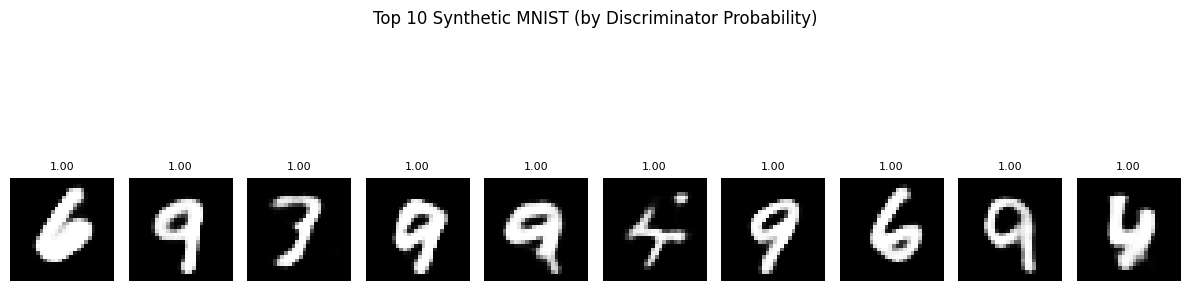

In [28]:
import matplotlib.pyplot as plt

# Get the top 10 indices with highest discriminator probabilities
topk = torch.topk(all_probs.squeeze(), 10)  # topk.values, topk.indices
topk_indices = topk.indices

# Get the corresponding images
top_images = synthetic_images[topk_indices]

# Plot the images
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(top_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{topk.values[i]:.2f}", fontsize=8)

plt.tight_layout()
plt.suptitle("Top 10 Synthetic MNIST (by Discriminator Probability)", y=1.05)
plt.show()


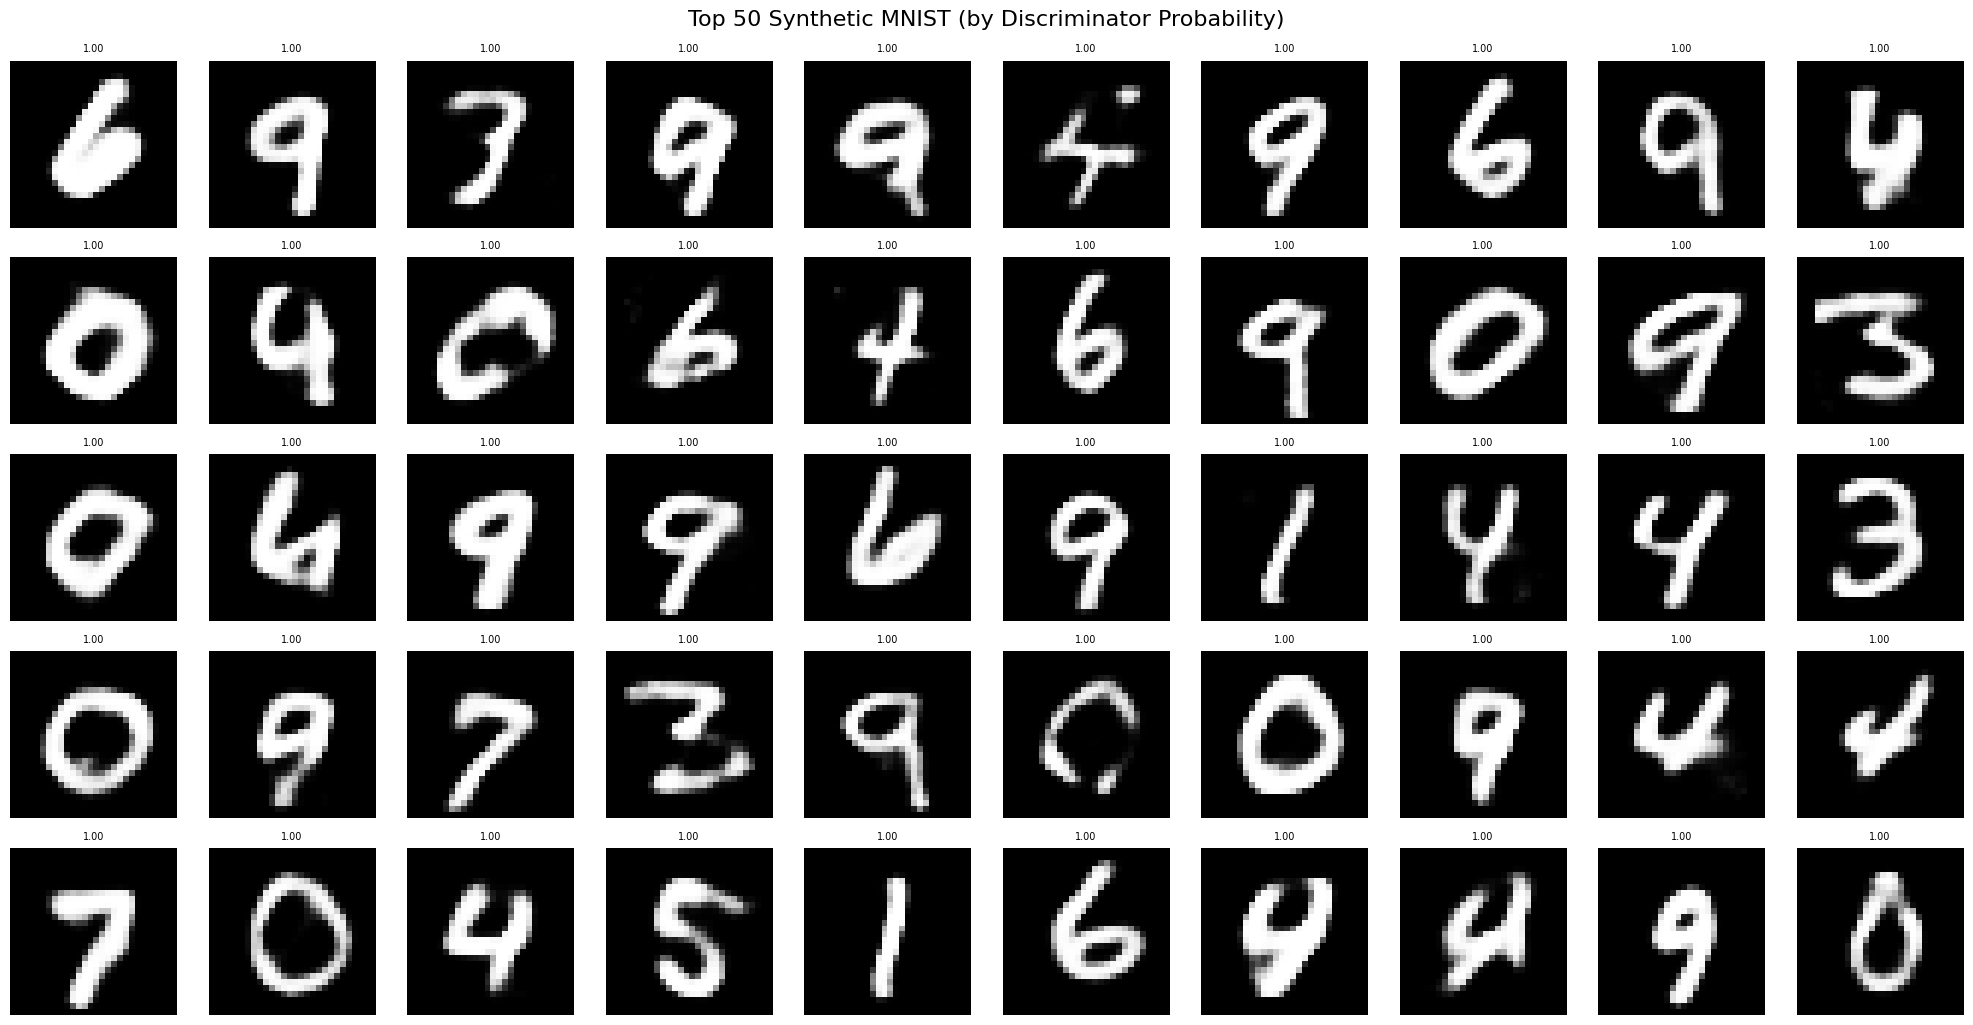

In [29]:
import matplotlib.pyplot as plt

# Get the top 50 indices with highest discriminator probabilities
topk = torch.topk(all_probs.squeeze(), 50)
topk_indices = topk.indices
top_images = synthetic_images[topk_indices]

# Plot in a 5x10 grid
plt.figure(figsize=(20, 10))
for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(top_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{topk.values[i]:.2f}", fontsize=7)

plt.tight_layout()
plt.suptitle("Top 50 Synthetic MNIST (by Discriminator Probability)", y=1.02, fontsize=16)
plt.show()


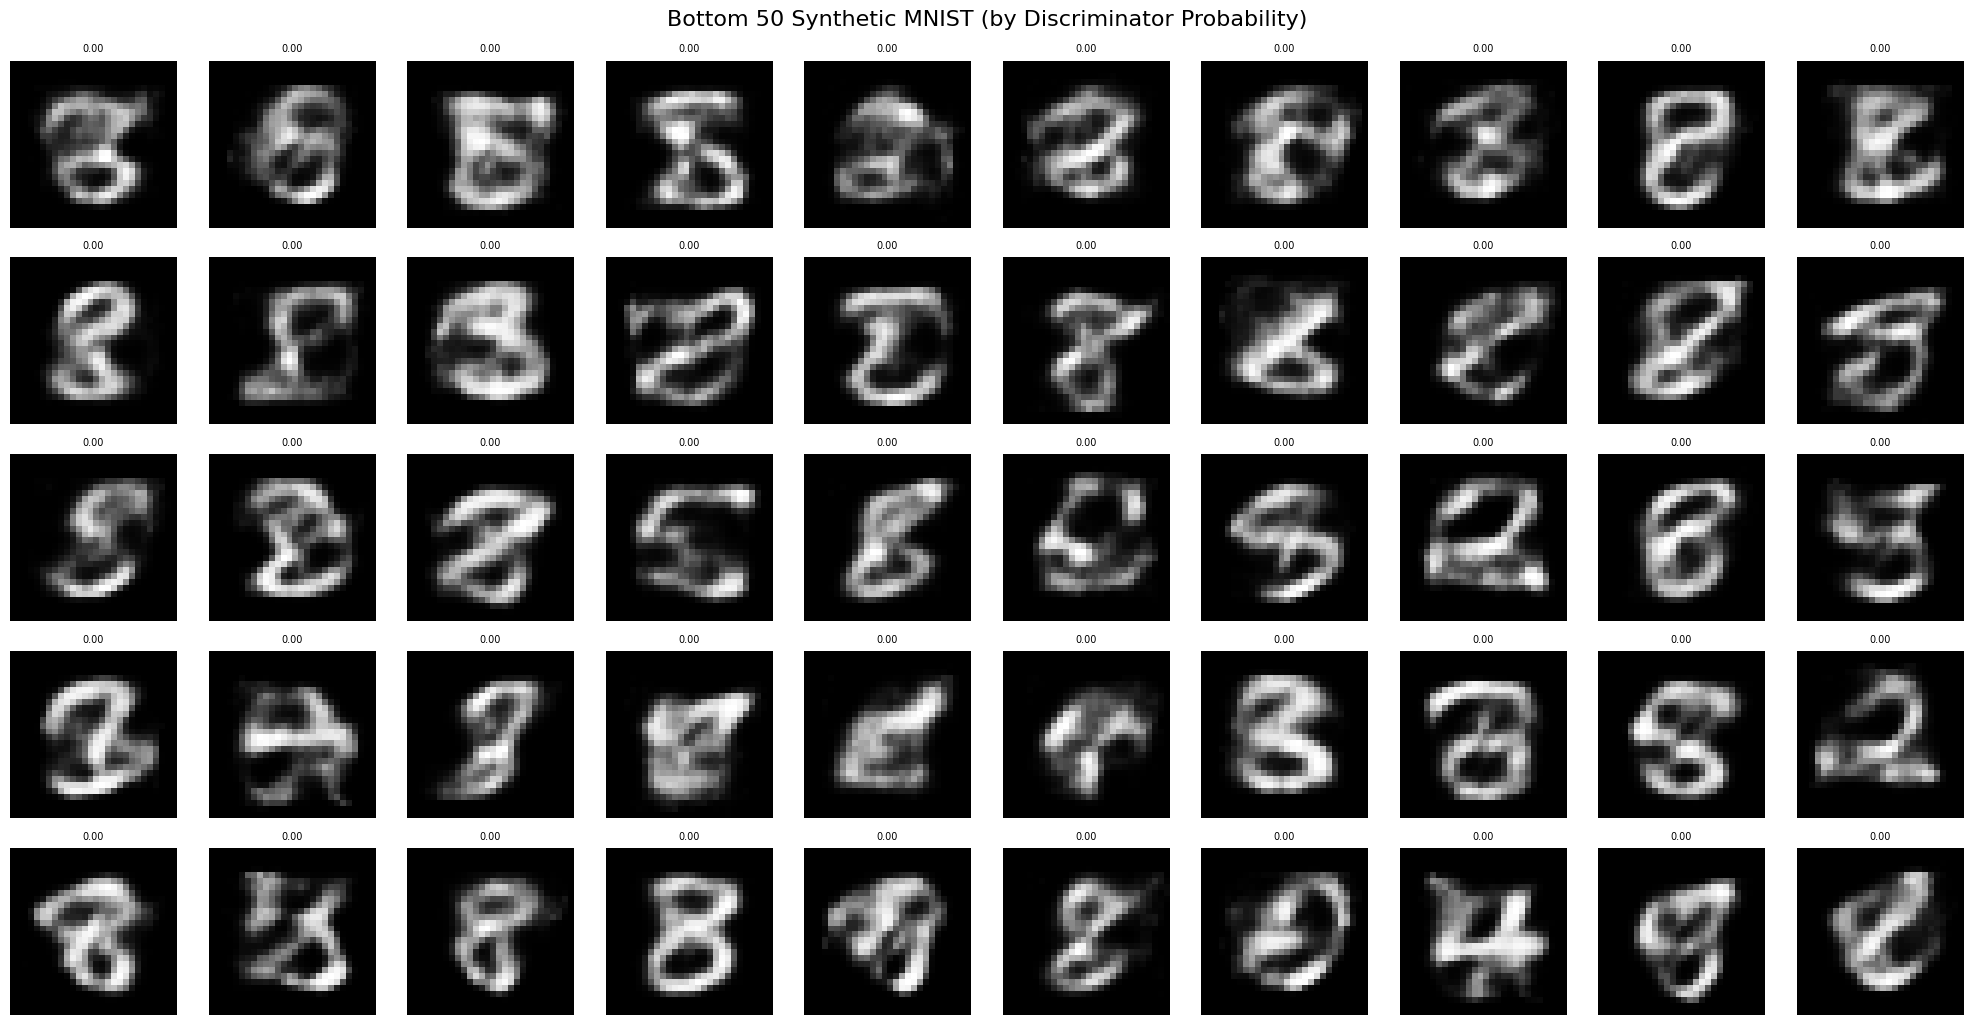

In [30]:
import matplotlib.pyplot as plt

# Get the bottom 50 indices with lowest discriminator probabilities
bottomk = torch.topk(all_probs.squeeze(), 50, largest=False)
bottomk_indices = bottomk.indices
bottom_images = synthetic_images[bottomk_indices]

# Plot in a 5x10 grid
plt.figure(figsize=(20, 10))
for i in range(50):
    plt.subplot(5, 10, i + 1)
    plt.imshow(bottom_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{bottomk.values[i]:.2f}", fontsize=7)

plt.tight_layout()
plt.suptitle("Bottom 50 Synthetic MNIST (by Discriminator Probability)", y=1.02, fontsize=16)
plt.show()


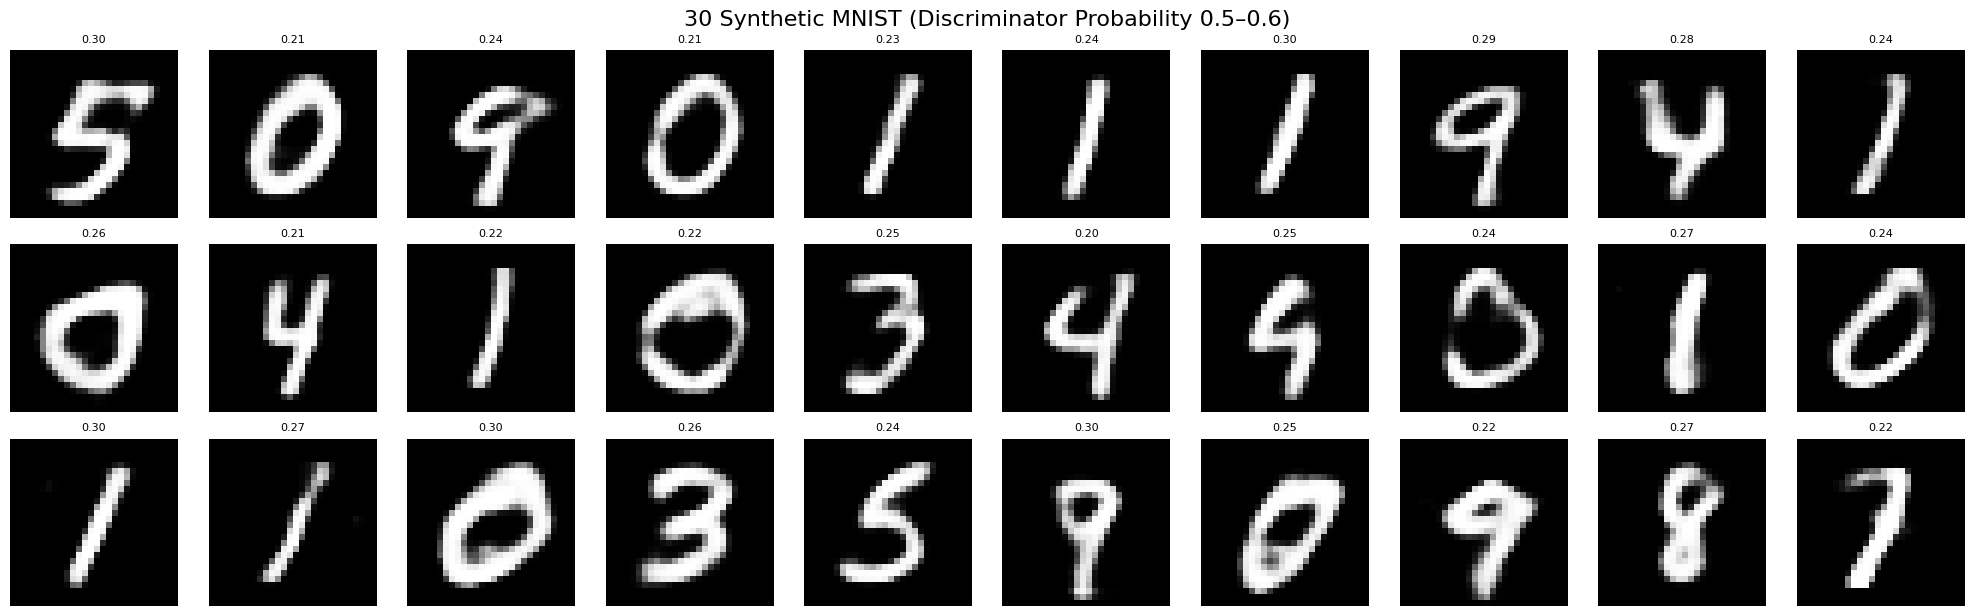

In [34]:
import matplotlib.pyplot as plt

# Step 1: Create mask for probabilities between 0.5 and 0.6
mask = (all_probs.squeeze() >= 0.2) & (all_probs.squeeze() <= 0.3)
indices_in_range = torch.nonzero(mask).squeeze()

# Step 2: Select 30 (randomly if more than 30 available)
if indices_in_range.numel() > 30:
    selected_indices = indices_in_range[torch.randperm(len(indices_in_range))[:30]]
else:
    selected_indices = indices_in_range

# Step 3: Get the images and their probabilities
selected_images = synthetic_images[selected_indices]
selected_probs = all_probs[selected_indices]

# Step 4: Plot in 3x10 grid
plt.figure(figsize=(20, 6))
for i in range(len(selected_images)):
    plt.subplot(3, 10, i + 1)
    plt.imshow(selected_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
    plt.title(f"{selected_probs[i].item():.2f}", fontsize=8)

plt.tight_layout()
plt.suptitle("30 Synthetic MNIST (Discriminator Probability 0.5–0.6)", y=1.02, fontsize=16)
plt.show()


Total samples with prob > 0.5: 603
Digit 0: 98 samples, ratio = 0.163
Digit 1: 95 samples, ratio = 0.158
Digit 2: 22 samples, ratio = 0.036
Digit 3: 52 samples, ratio = 0.086
Digit 4: 54 samples, ratio = 0.090
Digit 5: 9 samples, ratio = 0.015
Digit 6: 67 samples, ratio = 0.111
Digit 7: 74 samples, ratio = 0.123
Digit 8: 20 samples, ratio = 0.033
Digit 9: 112 samples, ratio = 0.186


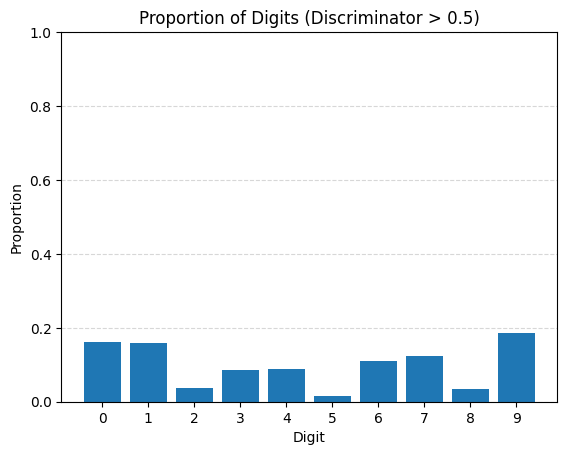

In [40]:
import torch
import matplotlib.pyplot as plt

# Step 1: Flatten the probabilities tensor
probs = all_probs.squeeze()  # shape: [60000]

# Step 2: Create mask for discriminator > 0.5
mask = probs > 0.5

# Step 3: Get corresponding labels for filtered samples
filtered_labels = labels[mask]  # shape: [N_filtered]

# Step 4: Count number of each digit (0–9)
counts = torch.bincount(filtered_labels, minlength=10)
total = counts.sum()
ratios = counts.float() / total

# Step 5: Print result
print(f"Total samples with prob > 0.5: {total.item()}")
for i in range(10):
    print(f"Digit {i}: {counts[i].item()} samples, ratio = {ratios[i]:.3f}")

# Step 6: Optional bar plot
plt.bar(range(10), ratios.numpy())
plt.xlabel("Digit")
plt.ylabel("Proportion")
plt.title("Proportion of Digits (Discriminator > 0.5)")
plt.xticks(range(10))
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


# Train the CVAE on the filered synthetic data

In [13]:
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn.functional as F
from cvae_model import CVAE, cvae_loss
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
latent_dim = 20
label_dim = 10
batch_size = 128
epochs = 100
lr = 1e-3

# Load filtered synthetic data
data = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")
images = data["images"]  # shape: [N, 1, 28, 28]
labels = data["labels"]  # shape: [N]

print(f"Loaded {images.shape[0]} filtered synthetic samples")

# Preprocess: flatten images and convert labels to one-hot
images = images.view(-1, 784)  # flatten to [N, 784]
labels_onehot = F.one_hot(labels, num_classes=label_dim).float()

# Create dataset and dataloader
dataset = TensorDataset(images, labels_onehot)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize model
model = CVAE(latent_dim=latent_dim, label_dim=label_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

# Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        recon_x, mu, logvar = model(x, y)
        loss = cvae_loss(recon_x, x, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader.dataset)
    print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")


/tmp/ipykernel_4165116/3026746600.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")


Loaded 75242 filtered synthetic samples
Epoch 1, Loss: 131.1006
Epoch 2, Loss: 95.1763
Epoch 3, Loss: 89.6107
Epoch 4, Loss: 87.0460
Epoch 5, Loss: 85.4998
Epoch 6, Loss: 84.4013
Epoch 7, Loss: 83.6176
Epoch 8, Loss: 82.9793
Epoch 9, Loss: 82.5366
Epoch 10, Loss: 82.1514
Epoch 11, Loss: 81.8642
Epoch 12, Loss: 81.5905
Epoch 13, Loss: 81.4186
Epoch 14, Loss: 81.2239
Epoch 15, Loss: 81.0852
Epoch 16, Loss: 80.9234
Epoch 17, Loss: 80.8507
Epoch 18, Loss: 80.7370
Epoch 19, Loss: 80.6225
Epoch 20, Loss: 80.5629
Epoch 21, Loss: 80.4603
Epoch 22, Loss: 80.3959
Epoch 23, Loss: 80.3371
Epoch 24, Loss: 80.2358
Epoch 25, Loss: 80.1897
Epoch 26, Loss: 80.1611
Epoch 27, Loss: 80.0786
Epoch 28, Loss: 80.0520
Epoch 29, Loss: 80.0149
Epoch 30, Loss: 79.9910
Epoch 31, Loss: 79.9485
Epoch 32, Loss: 79.9184
Epoch 33, Loss: 79.8744
Epoch 34, Loss: 79.8245
Epoch 35, Loss: 79.8101
Epoch 36, Loss: 79.7535
Epoch 37, Loss: 79.7431
Epoch 38, Loss: 79.7177
Epoch 39, Loss: 79.6840
Epoch 40, Loss: 79.6235
Epoch 41

In [14]:
# save the model to model_saved folder
import os
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
torch.save(model.state_dict(), f"model_saved/cvae_mnist_filtered_synthetic_data.pth")
print(f"Model saved to model_saved/cvae_mnist_filtered_synthetic_data.pth")

Model saved to model_saved/cvae_mnist_filtered_synthetic_data.pth


In [17]:
# use the new model to generate 60000 samples
import sys
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
import torch
from cvae_model import CVAE 
import os

latent_dim = 20
label_dim = 10
model = CVAE(latent_dim=latent_dim, label_dim=label_dim)
#os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")  
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
model.load_state_dict(torch.load("model_saved/cvae_mnist_filtered_synthetic_data.pth"))
model.eval()


import torch
import torch.nn.functional as F

model.eval()

n_per_class = 60000
num_classes = 10
total_samples = n_per_class * num_classes
latent_dim = model.latent_dim
device = next(model.parameters()).device

z = torch.randn(total_samples, latent_dim).to(device)
y = torch.arange(num_classes).repeat_interleave(n_per_class)
y_onehot = F.one_hot(y, num_classes=num_classes).float().to(device)

with torch.no_grad():
    gen_imgs = model.decode(z, y_onehot).view(-1, 1, 28, 28).cpu()  # shape: [60000, 1, 28, 28]


/tmp/ipykernel_4165116/1903444756.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model_saved/cvae_mnist_filtered_synthetic_data.pth")

In [18]:
# save the generated images and labels
import torch
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
save_path = "data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data.pt"
torch.save({"images": gen_imgs, "labels": y}, save_path)
print(f"Generated images and labels saved to {save_path}")


Generated images and labels saved to data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data.pt


# FID

In [5]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import TensorDataset
import os
import sys
import torch
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

from FID import calculate_fid_score

transform = transforms.ToTensor()

# Real MNIST
real_ds = MNIST(root='./data', train=True, download=True, transform=transform)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
# Synthetic dataset
synthetic = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))

# FID computation
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score: {fid_value:.2f}")

/tmp/ipykernel_2880900/3012547288.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")
Extracting featur

FID Score: 0.02


In [27]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import TensorDataset
import os
import sys
import torch
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

from FID import calculate_fid_score

transform = transforms.ToTensor()

# Real MNIST
real_ds = MNIST(root='./data', train=True, download=True, transform=transform)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
# Synthetic dataset
synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))

# FID computation
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score: {fid_value:.2f}")

/tmp/ipykernel_4165116/344026103.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")
Extracting featu

FID Score: 0.03


In [19]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import TensorDataset
import os
import sys
import torch
sys.path.append("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")

from FID import calculate_fid_score

transform = transforms.ToTensor()

# Real MNIST
real_ds = MNIST(root='./data', train=True, download=True, transform=transform)
os.chdir("/home/qiyuanliu/data_filter/Verified-Synthetic-Data/MNIST")
# Synthetic dataset
synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data.pt")
synthetic_ds = TensorDataset(synthetic['images'], torch.zeros(len(synthetic['images'])))

# FID computation
fid_value = calculate_fid_score(real_ds, synthetic_ds)
print(f"FID Score: {fid_value:.2f}")

/tmp/ipykernel_4165116/398919200.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_genera

FID Score: 0.08


/tmp/ipykernel_4165116/905146133.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")


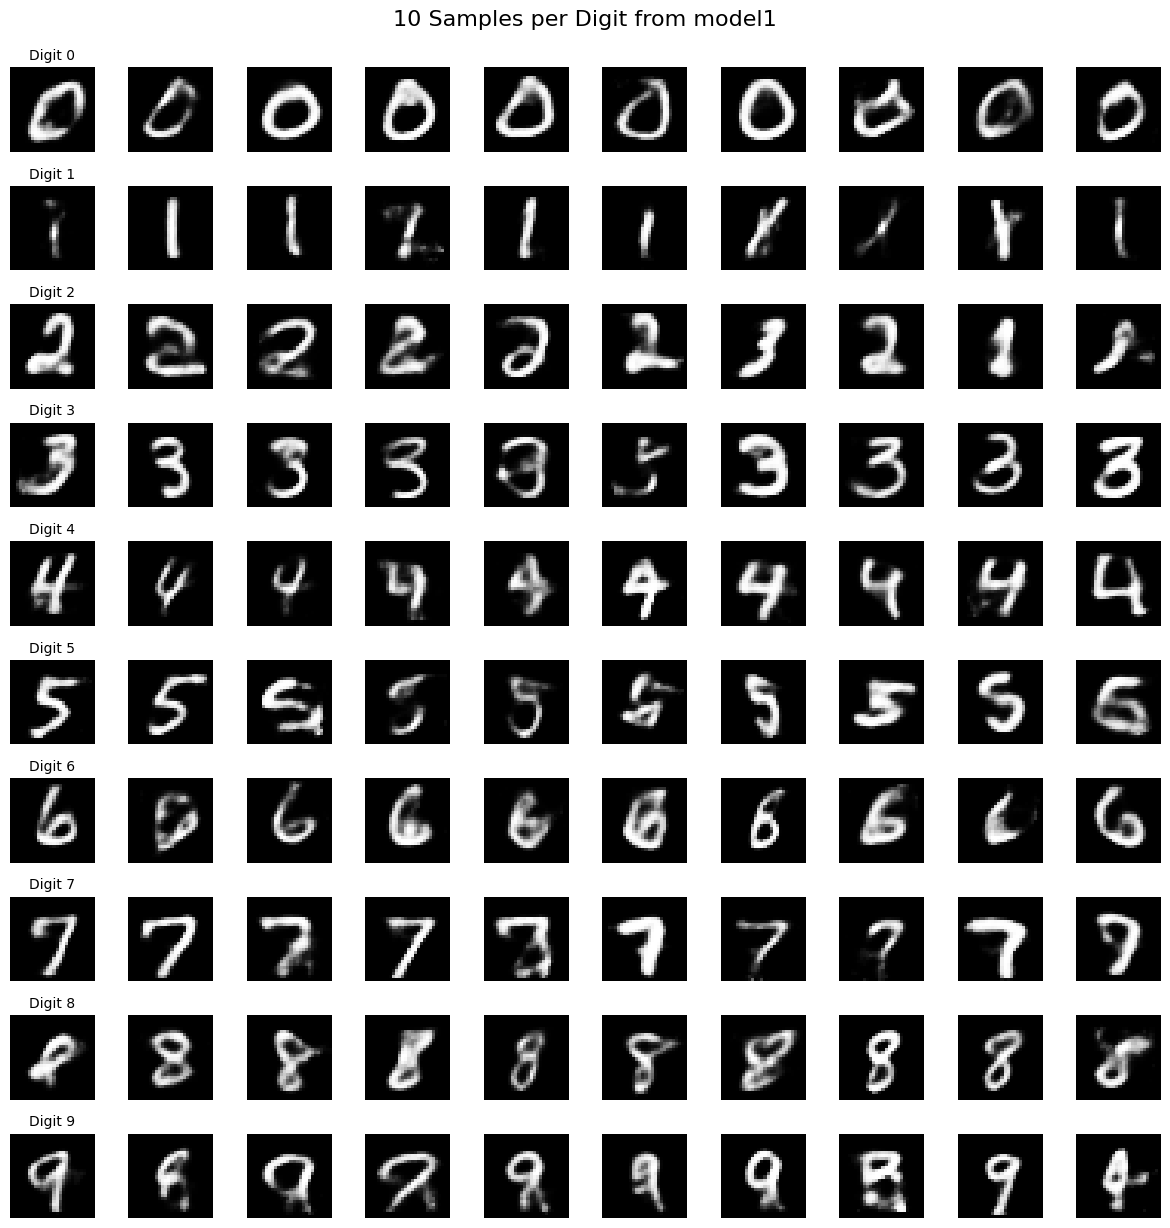

In [23]:
import torch
import matplotlib.pyplot as plt

# Load synthetic data
synthetic = torch.load("data_saved/synthetic_mnist_cvae_60000_2.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model1", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_4165116/156800624.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generat

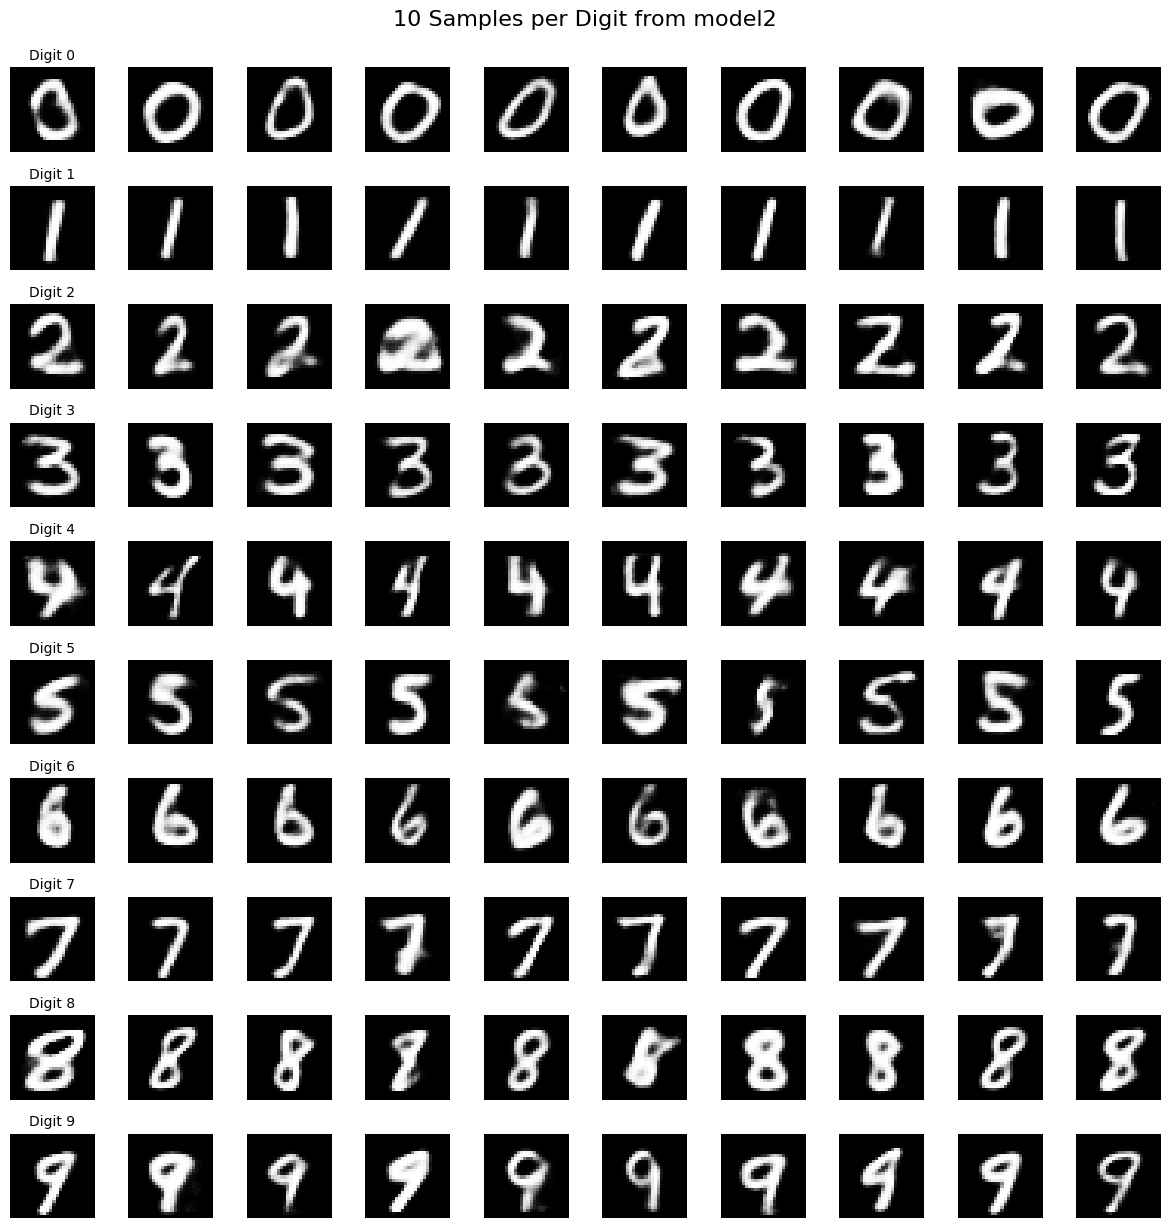

In [ ]:
import torch
import matplotlib.pyplot as plt

# Load synthetic data
synthetic = torch.load("data_saved/synthetic_mnist_cvae_filtered_synthetic_model_generated_data.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from model2", y=1.02, fontsize=16)
plt.show()


/tmp/ipykernel_4165116/1236427949.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")


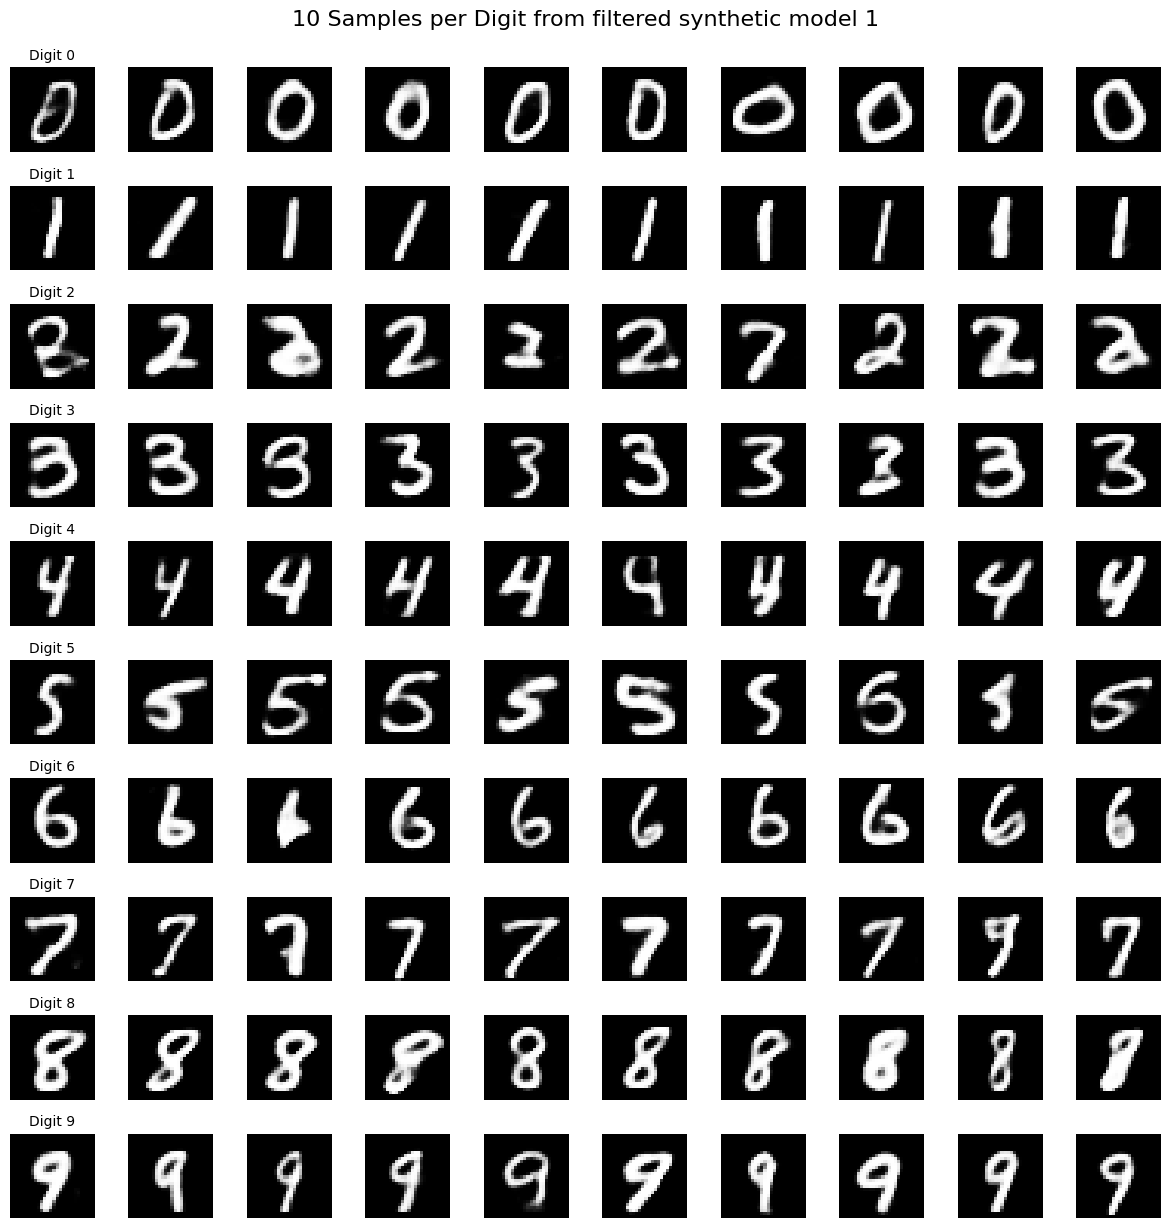

In [25]:
# load the filtered synthetic data
import torch
synthetic = torch.load("data_saved/synthetic_mnist_filtered_pgt05.pt")
images = synthetic["images"]  # [N, 1, 28, 28]
labels = synthetic["labels"]  # [N]

# Ensure on CPU for plotting
images = images.cpu()
labels = labels.cpu()

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for digit in range(10):
    digit_indices = (labels == digit).nonzero(as_tuple=True)[0]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(images[idx].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)

plt.tight_layout()
plt.suptitle("10 Samples per Digit from filtered synthetic model 1", y=1.02, fontsize=16)
plt.show()


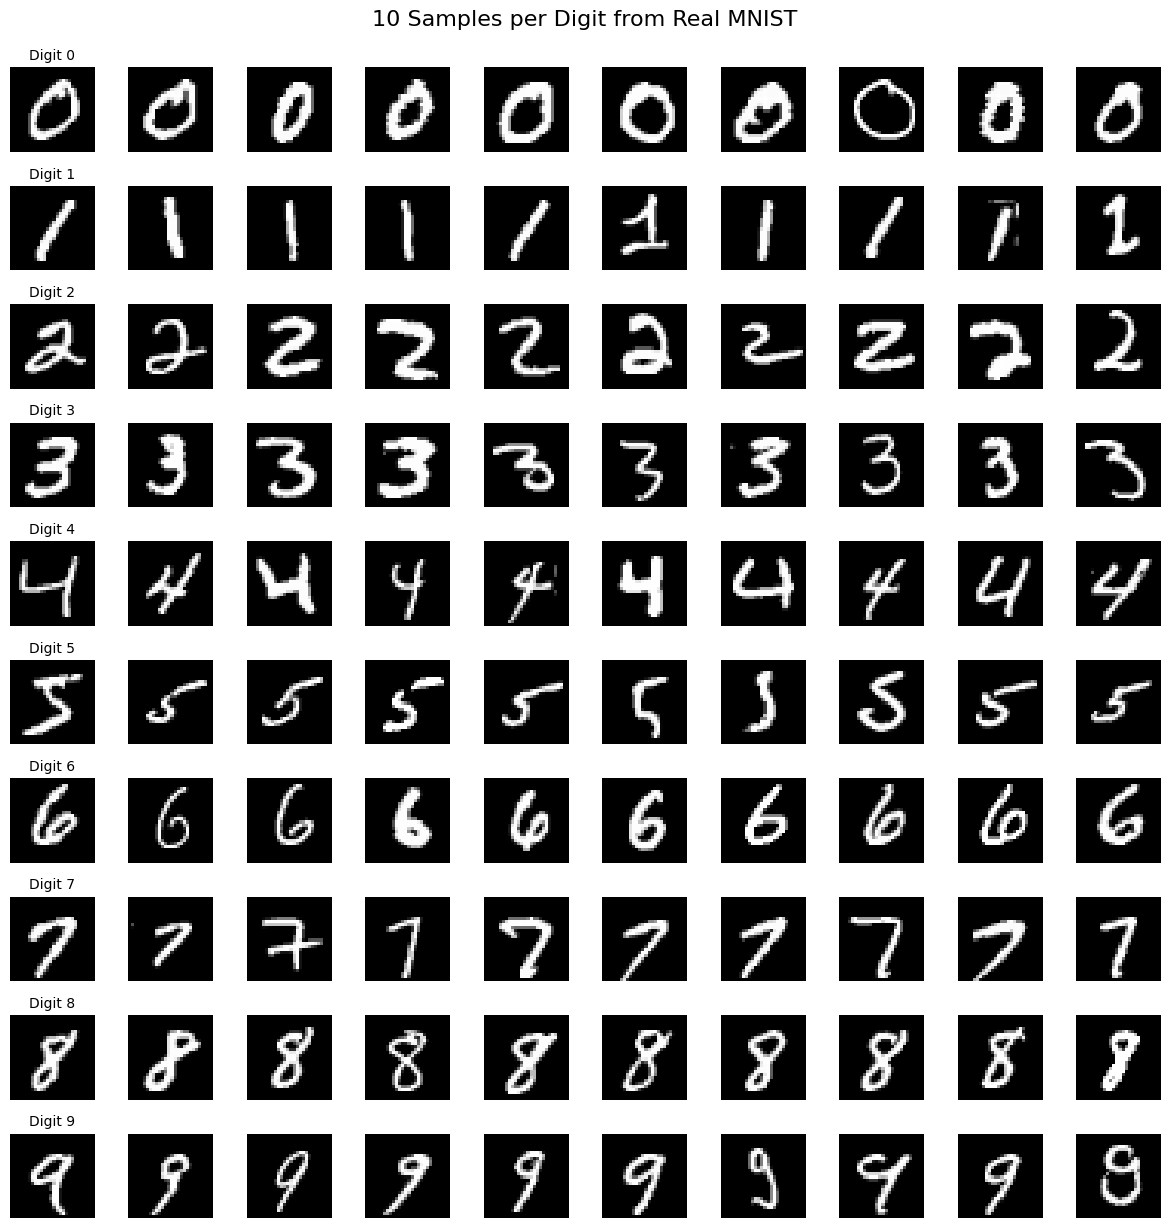

In [26]:
# real data
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
# Load real MNIST data
transform = transforms.ToTensor()
mnist_real = datasets.MNIST(root='./data', train=True, download=True, transform =transform)

# Plot 10 samples for each digit
fig, axes = plt.subplots(10, 10, figsize=(12, 12))
for digit in range(10):
    digit_indices = [i for i, (_, label) in enumerate(mnist_real) if label == digit]
    selected_indices = digit_indices[:10]  # take first 10

    for i, idx in enumerate(selected_indices):
        ax = axes[digit, i]
        ax.imshow(mnist_real[idx][0].squeeze(), cmap="gray")
        ax.axis("off")
        if i == 0:
            ax.set_title(f"Digit {digit}", fontsize=10)
plt.tight_layout()
plt.suptitle("10 Samples per Digit from Real MNIST", y=1.02, fontsize=16)
plt.show()